### Uppgift 0


a. hur många länder som är med i datan?


In [11]:
import pandas as pd

olympics = pd.read_csv("./data/athlete_events.csv")
unique_countries = olympics["NOC"].unique()

len(unique_countries)

230

b. vilka länder är med? (förkortningarna räcker)


In [12]:
unique_countries

array(['CHN', 'DEN', 'NED', 'USA', 'FIN', 'NOR', 'ROU', 'EST', 'FRA',
       'MAR', 'ESP', 'EGY', 'IRI', 'BUL', 'ITA', 'CHA', 'AZE', 'SUD',
       'RUS', 'ARG', 'CUB', 'BLR', 'GRE', 'CMR', 'TUR', 'CHI', 'MEX',
       'URS', 'NCA', 'HUN', 'NGR', 'ALG', 'KUW', 'BRN', 'PAK', 'IRQ',
       'UAR', 'LIB', 'QAT', 'MAS', 'GER', 'CAN', 'IRL', 'AUS', 'RSA',
       'ERI', 'TAN', 'JOR', 'TUN', 'LBA', 'BEL', 'DJI', 'PLE', 'COM',
       'KAZ', 'BRU', 'IND', 'KSA', 'SYR', 'MDV', 'ETH', 'UAE', 'YAR',
       'INA', 'PHI', 'SGP', 'UZB', 'KGZ', 'TJK', 'EUN', 'JPN', 'CGO',
       'SUI', 'BRA', 'FRG', 'GDR', 'MON', 'ISR', 'URU', 'SWE', 'ISV',
       'SRI', 'ARM', 'CIV', 'KEN', 'BEN', 'UKR', 'GBR', 'GHA', 'SOM',
       'LAT', 'NIG', 'MLI', 'AFG', 'POL', 'CRC', 'PAN', 'GEO', 'SLO',
       'CRO', 'GUY', 'NZL', 'POR', 'PAR', 'ANG', 'VEN', 'COL', 'BAN',
       'PER', 'ESA', 'PUR', 'UGA', 'HON', 'ECU', 'TKM', 'MRI', 'SEY',
       'TCH', 'LUX', 'MTN', 'CZE', 'SKN', 'TTO', 'DOM', 'VIN', 'JAM',
       'LBR', 'SUR',

c. vilka sporter är med?


In [13]:
unique_sports = olympics["Sport"].nunique()

unique_sports

66

d. vilka medaljtyper finns det?


In [14]:
unique_medals = olympics["Medal"].dropna().unique()
unique_medals

array(['Gold', 'Bronze', 'Silver'], dtype=object)

e. ta reda på statistik för åldern: medelvärde, median, min, max, standardavvikelse,


In [15]:
olympics["Age"].describe(percentiles=[0.5])

count    261642.000000
mean         25.556898
std           6.393561
min          10.000000
50%          24.000000
max          97.000000
Name: Age, dtype: float64

f. utforska datan vidare med egna frågor


In [16]:
import plotly.express as px

# number of male and female athletes

unique_athletes = olympics.drop_duplicates(subset="ID")

gender_counts = unique_athletes["Sex"].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Gender distribution (unique athletes)",
)

fig.show()

⚠️ Unmapped NOCs (add to FOLD_MAP or noc_regions): ['ROT', 'TUV', 'UNK']


[Text(0.5, 1.0, 'Top 10 Medal counts (total) by medal type')]

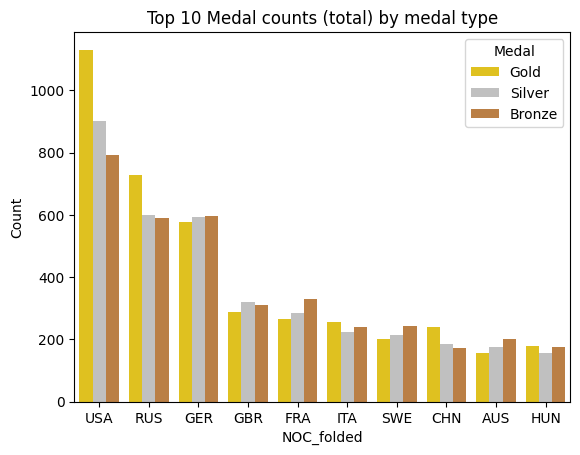

In [17]:
import seaborn as sns
from normalize_noc import normalize_noc

# top 10 medals

noc = pd.read_csv("./data/noc_regions.csv")

clean = normalize_noc(olympics, noc)

event_medals = (
    clean[clean["Medal"].notna()]
    .drop_duplicates(subset=["Games","Event","NOC_folded","Medal"])
)

medals_by_type = (event_medals.groupby(["NOC_folded", "Medal"])).size().unstack(fill_value=0)
medals_by_type["Total"] = medals_by_type.sum(axis=1)

top_10_medals = medals_by_type.sort_values("Total", ascending=False).head(10)

top_10_melted = top_10_medals.reset_index().melt(
    id_vars="NOC_folded",
    value_vars=["Gold", "Silver", "Bronze"],
    var_name="Medal",
    value_name="Count",
)

sns.barplot(
    top_10_melted,
    x="NOC_folded",
    y="Count",
    hue="Medal",
    palette={"Gold": "#FFD700", "Silver": "#C0C0C0", "Bronze": "#CD7F32"},
).set(title="Top 10 Medal counts (total) by medal type")


In [18]:
import plotly.express as px

medals_per_country = event_medals.groupby("NOC_folded").size().reset_index(name="Medal Count")

merged = medals_per_country.merge(
    noc[["NOC", "region"]].rename(columns={"NOC": "NOC_folded"}),
    on="NOC_folded",
    how="left"
)

fig = px.choropleth(
    merged,
    locations="region",
    locationmode="country names",
    color="Medal Count",
    hover_name="region",
    color_continuous_scale="YlOrRd",
    title="Total Olympic medals by country",
    projection="natural earth",
)

fig.show()


/var/folders/z6/lqrq2m_5737_gdx8z2b2c2v00000gn/T/ipykernel_51510/3235211478.py:11: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [19]:
yearly_medals = event_medals.groupby(["Year", "NOC"]).size().reset_index(name="Count")

yearly_medals = yearly_medals.merge(
    noc[["NOC", "region"]], on="NOC", how="left"
)

yearly_medals = yearly_medals.dropna(subset=["region"])

fig = px.choropleth(
    yearly_medals,
    locations="region",
    locationmode="country names",
    color="Count",
    hover_name="region",
    animation_frame="Year",
    color_continuous_scale="Plasma",
    title="Olympic medals over time",
)
fig.show()

/var/folders/z6/lqrq2m_5737_gdx8z2b2c2v00000gn/T/ipykernel_51510/959126720.py:9: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



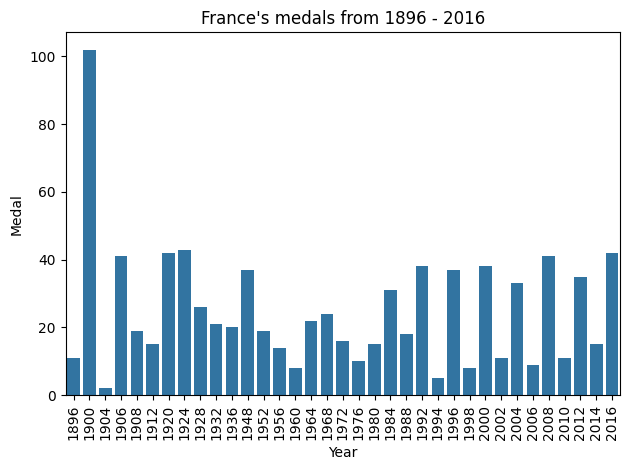

In [20]:
import matplotlib.pyplot as plt

france_medals = (
    event_medals[event_medals["NOC"] == "FRA"]
    .groupby("Year")["Medal"]
    .size()
)
france_medals = pd.DataFrame(france_medals)

sns.barplot(france_medals, x="Year", y="Medal").set(
    title="France's medals from 1896 - 2016"
)
plt.xticks(rotation=90)
plt.tight_layout()
